In [3]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')

arquivo = '/content/drive/MyDrive/Colab Notebooks/Datathon Fase 5/FIAP/df_combinado.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df_analise = pd.read_csv(arquivo)

display(df_analise.head())

,RA,Genero,Fase,Defasagem,Pedra,IAN,IDA,IEG,IAA,IPS,IPV,INDE,IPP,AnoRef
0,1,Feminino,7,-1,Quartzo,5.0,4.0,4.1,8.3,5.6,7.278,5.783,7.437500,2022
1,2,Feminino,7,0,Ametista,10.0,6.8,5.2,8.8,6.3,6.778,7.055,7.443750,2022
2,3,Feminino,7,0,Ágata,10.0,5.6,7.9,0.0,5.6,7.556,6.591,7.193750,2022
3,4,Masculino,7,0,Quartzo,10.0,5.0,4.5,8.8,5.6,5.278,5.951,6.316667,2022
4,5,Feminino,7,0,Ametista,10.0,5.2,8.6,7.9,5.6,7.389,7.427,7.500000,2022


#1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? (Ex.: quantos alunos estão moderadamente ou severamente defasados?)

Resumo geral do IAN:


,IAN_grupo,Total_Alunos,Percentual
0,Defasagem Moderada,3499,56.154710
1,Em Fase,2655,42.609533
2,Defasagem Severa,77,1.235757


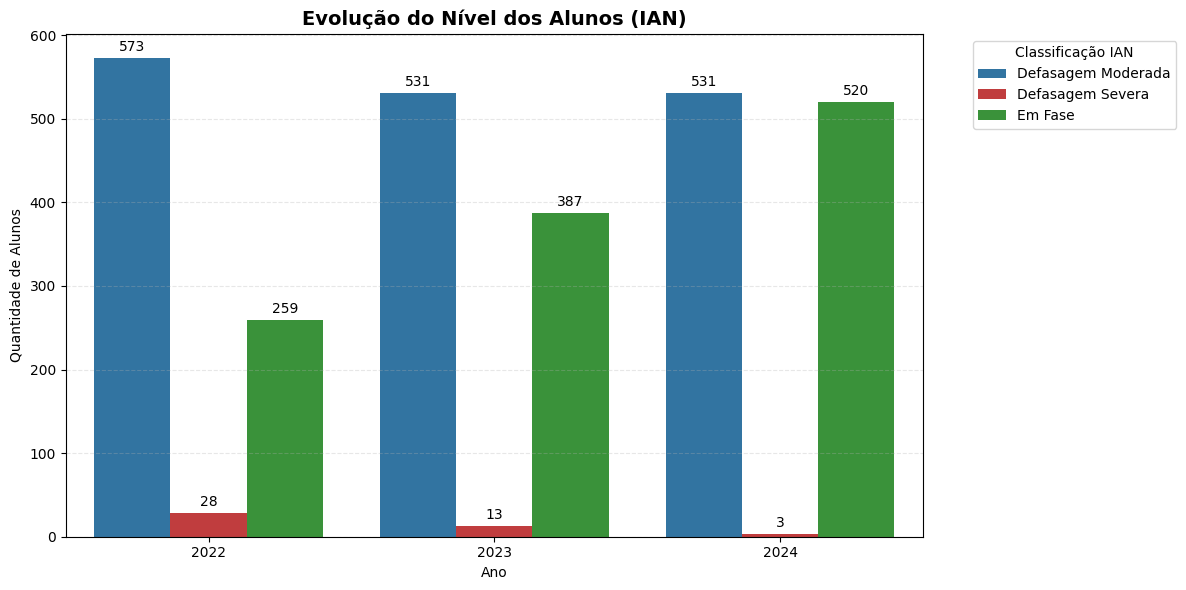


 INSIGHTS AUTOMÁTICOS:

Defasagem Moderada: 56.2% dos alunos
Em Fase: 42.6% dos alunos
Defasagem Severa: 1.2% dos alunos

 Destaque:
- Alta concentração em Defasagem Moderada (ponto de atenção)
- Baixo nível de Defasagem Severa (bom sinal)
- Boa quantidade de alunos em nível adequado


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Criar coluna categórica IAN

def criar_grupo_ian(df):
    ian_dict = {
        2.5: 'Defasagem Severa',
        5.0: 'Defasagem Moderada',
        10.0: 'Em Fase'
    }

    df = df.copy()
    df['IAN_grupo'] = df['IAN'].map(ian_dict)

    return df

df_analise = criar_grupo_ian(df_analise)

# Distribuição geral

def resumo_ian(df):
    resumo = df['IAN_grupo'].value_counts().reset_index()
    resumo.columns = ['IAN_grupo', 'Total_Alunos']

    resumo['Percentual'] = (resumo['Total_Alunos'] / resumo['Total_Alunos'].sum()) * 100

    return resumo

resumo = resumo_ian(df_analise)
print("Resumo geral do IAN:")
display(resumo)

# Evolução por ano

def evolucao_ian(df):
    evolucao = (
        df.groupby(['AnoRef', 'IAN_grupo'])['RA']
        .nunique()
        .reset_index(name='Total_Alunos')
    )
    return evolucao

df_evolucao = evolucao_ian(df_analise)

# Gráfico

def plot_evolucao(df):
    plt.figure(figsize=(12, 6))

    palette = {
        'Defasagem Severa': '#d62728',
        'Defasagem Moderada': '#1f77b4',
        'Em Fase': '#2ca02c'
    }

    ax = sns.barplot(
        data=df,
        x='AnoRef',
        y='Total_Alunos',
        hue='IAN_grupo',
        palette=palette
    )

    # Rótulos nas barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

    plt.title('Evolução do Nível dos Alunos (IAN)', fontsize=14, weight='bold')
    plt.xlabel('Ano')
    plt.ylabel('Quantidade de Alunos')

    plt.legend(title='Classificação IAN', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_evolucao(df_evolucao)

# Insight automático (extra)


def gerar_insights(df):
    print("\n INSIGHTS:\n")

    resumo = df['IAN_grupo'].value_counts(normalize=True) * 100

    for grupo, perc in resumo.items():
        print(f"{grupo}: {perc:.1f}% dos alunos")

    print("\n Destaque:")

    if resumo.get('Defasagem Moderada', 0) > 50:
        print("- Alta concentração em Defasagem Moderada (ponto de atenção)")

    if resumo.get('Defasagem Severa', 0) < 5:
        print("- Baixo nível de Defasagem Severa (bom sinal)")

    if resumo.get('Em Fase', 0) > 30:
        print("- Boa quantidade de alunos em nível adequado")

gerar_insights(df_analise)

#2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [ ]:
# Média do IDA por ano

def media_ida_por_ano(df):
    resultado = (
        df.groupby('AnoRef')['IDA']
        .mean()
        .reset_index()
        .rename(columns={'IDA': 'Media_IDA'})
    )

    # Calcular variação ano a ano
    resultado['Variacao'] = resultado['Media_IDA'].diff()

    return resultado

df_ida_ano = media_ida_por_ano(df_analise)

print("Média do IDA por ano:")
display(df_ida_ano)

Média do IDA por ano:


,AnoRef,Media_IDA,Variacao
0,2022,6.353387,NaN
1,2023,6.702157,0.348770
2,2024,6.317700,-0.384457


Insight

2022 → 2023: melhora significativa

2023 → 2024: queda relevante

Resultado geral:

O desempenho apresenta comportamento instável, com melhora inicial seguida de regressão.

In [ ]:
#IDA por fase e ano


def media_ida_fase_ano(df):
    return (
        df.groupby(['AnoRef', 'Fase'])['IDA']
        .mean()
        .reset_index()
        .rename(columns={'IDA': 'Media_IDA'})
    )

df_fase_ano = media_ida_fase_ano(df_analise)

# Filtrar 2024
ida_2024 = df_fase_ano[df_fase_ano['AnoRef'] == 2024]

print("IDA por fase (2024):")
display(ida_2024.sort_values(by='Media_IDA', ascending=False))

IDA por fase (2024):


,AnoRef,Fase,Media_IDA
22,2024,6,7.415064
16,2024,0,7.200000
17,2024,1,6.678184
21,2024,5,6.639130
18,2024,2,6.382538
23,2024,7,6.187057
20,2024,4,5.981812
19,2024,3,5.423642


Insight importante:

Existe uma queda clara de desempenho nas fases intermediárias (3 e 4), indicando possível dificuldade pedagógica nesse ponto da jornada.

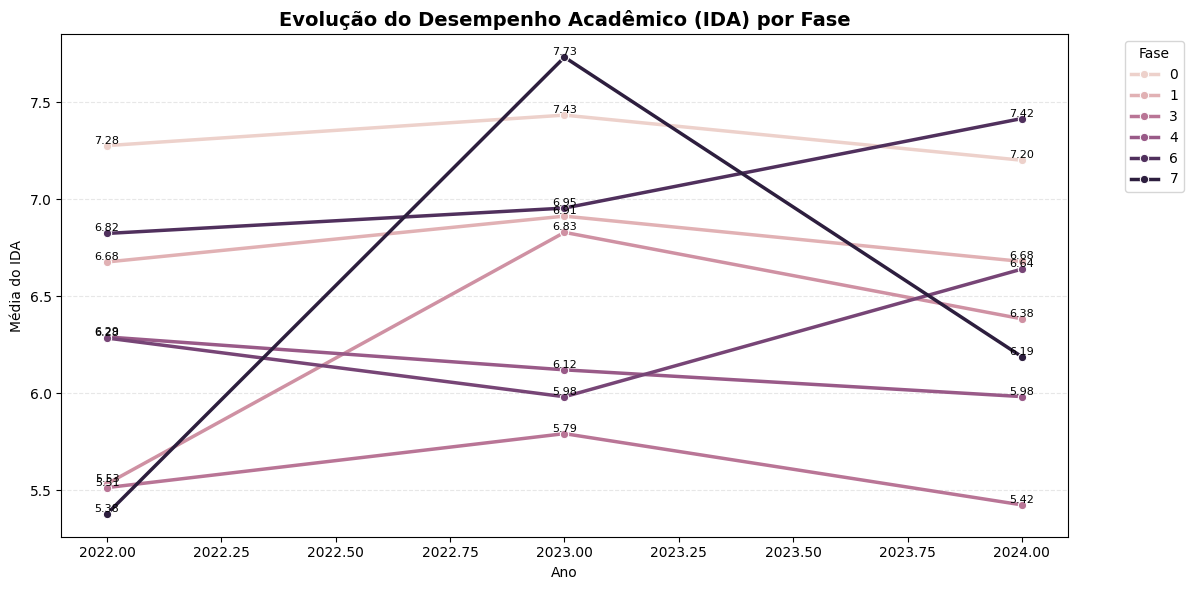

In [ ]:
#Gráfico de evolução


def plot_ida_fases(df):
    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(
        data=df,
        x='AnoRef',
        y='Media_IDA',
        hue='Fase',
        marker='o',
        linewidth=2.5
    )

    # Adicionar rótulos
    for line in ax.lines:
        x_data = line.get_xdata()
        y_data = line.get_ydata()

        for x, y in zip(x_data, y_data):
            plt.text(x, y, f'{y:.2f}', fontsize=8, ha='center', va='bottom')

    plt.title('Evolução do Desempenho Acadêmico (IDA) por Fase', fontsize=14, weight='bold')
    plt.xlabel('Ano')
    plt.ylabel('Média do IDA')

    plt.legend(title='Fase', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_ida_fases(df_fase_ano)

In [ ]:
#Análise automática por fase


def analisar_tendencia(df):
    print("\nINSIGHTS POR FASE:\n")

    fases = df['Fase'].unique()

    for fase in sorted(fases):
        dados = df[df['Fase'] == fase].sort_values('AnoRef')

        if len(dados) >= 2:
            variacao = dados['Media_IDA'].iloc[-1] - dados['Media_IDA'].iloc[0]

            if variacao > 0.2:
                tendencia = "📈 Melhora"
            elif variacao < -0.2:
                tendencia = "📉 Piora"
            else:
                tendencia = "➖ Estável"

            print(f"Fase {fase}: {tendencia} ({variacao:.2f})")

analisar_tendencia(df_fase_ano)


INSIGHTS POR FASE:

Fase 0: ➖ Estável (-0.08)
Fase 1: ➖ Estável (0.00)
Fase 2: 📈 Melhora (0.85)
Fase 3: ➖ Estável (-0.09)
Fase 4: 📉 Piora (-0.31)
Fase 5: 📈 Melhora (0.36)
Fase 6: 📈 Melhora (0.59)
Fase 7: 📈 Melhora (0.81)


O principal gargalo não está no início nem no fim — Está no meio da jornada do aluno.

O desempenho acadêmico (IDA) apresenta evolução inconsistente, com melhora inicial seguida de queda recente. As fases intermediárias (3 e 4) concentram os principais desafios, indicando a necessidade de intervenções pedagógicas específicas nesse ponto do ciclo educacional.

#3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

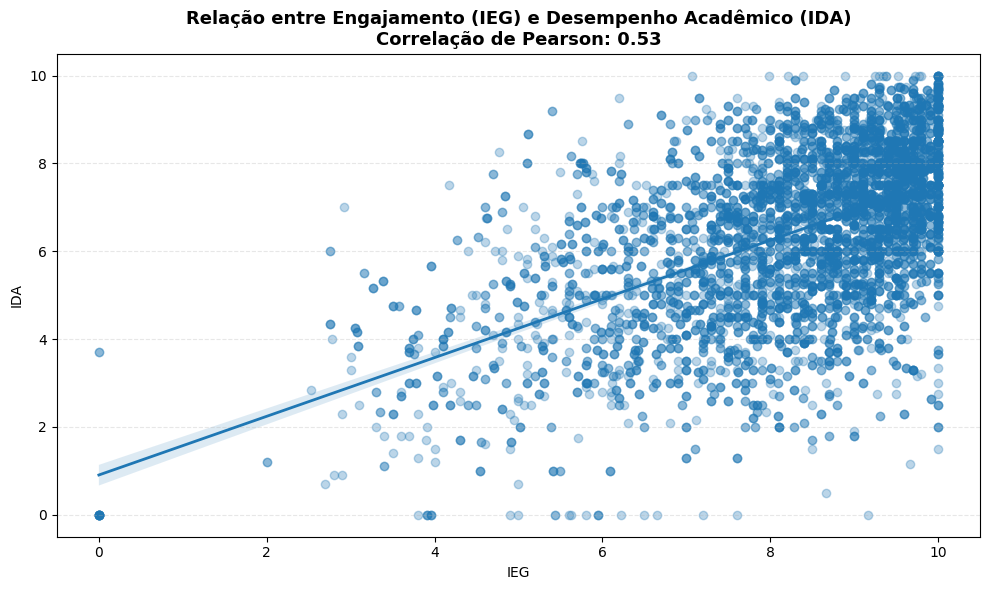

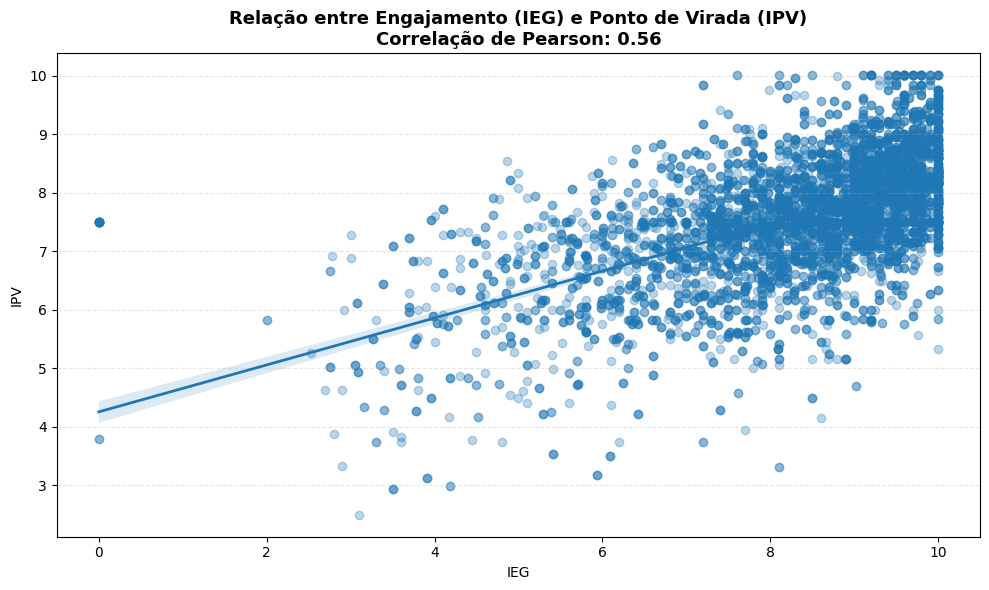

In [ ]:
# Função de análise de correlação


import matplotlib.pyplot as plt
import seaborn as sns

def analisar_relacao(df, x, y, titulo):
    plt.figure(figsize=(10, 6))

    ax = sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={'alpha': 0.3},
        line_kws={'linewidth': 2}
    )

    # Correlação
    corr = df[x].corr(df[y])

    # Título com correlação
    plt.title(f'{titulo}\nCorrelação de Pearson: {corr:.2f}', fontsize=13, weight='bold')

    plt.xlabel(x)
    plt.ylabel(y)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return corr

#IEG vs IDA


corr_ida = analisar_relacao(
    df_analise,
    x='IEG',
    y='IDA',
    titulo='Relação entre Engajamento (IEG) e Desempenho Acadêmico (IDA)'
)


#IEG vs IPV

corr_ipv = analisar_relacao(
    df_analise,
    x='IEG',
    y='IPV',
    titulo='Relação entre Engajamento (IEG) e Ponto de Virada (IPV)'
)

Quanto maior o engajamento (IEG), maior tende a ser o desempenho (IDA) e o ponto de virada (IPV).



In [ ]:
#Classificação da correlação


def classificar_correlacao(valor):
    if abs(valor) < 0.3:
        return "Fraca"
    elif abs(valor) < 0.7:
        return "Moderada"
    else:
        return "Forte"

print("\n📊 INTERPRETAÇÃO AUTOMÁTICA:\n")
print(f"IEG vs IDA: {corr_ida:.2f} → {classificar_correlacao(corr_ida)}")
print(f"IEG vs IPV: {corr_ipv:.2f} → {classificar_correlacao(corr_ipv)}")


📊 INTERPRETAÇÃO AUTOMÁTICA:

IEG vs IDA: 0.53 → Moderada
IEG vs IPV: 0.56 → Moderada


Existe uma relação positiva moderada entre o engajamento dos alunos (IEG) e seus indicadores de desempenho (IDA e IPV). Isso indica que alunos mais engajados tendem a apresentar melhores resultados acadêmicos e maior evolução, embora o engajamento não seja o único fator determinante.

- Engajamento é muito importante — Mas não explica tudo
- Melhor estratégia: engajamento + intervenção pedagógica

#4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

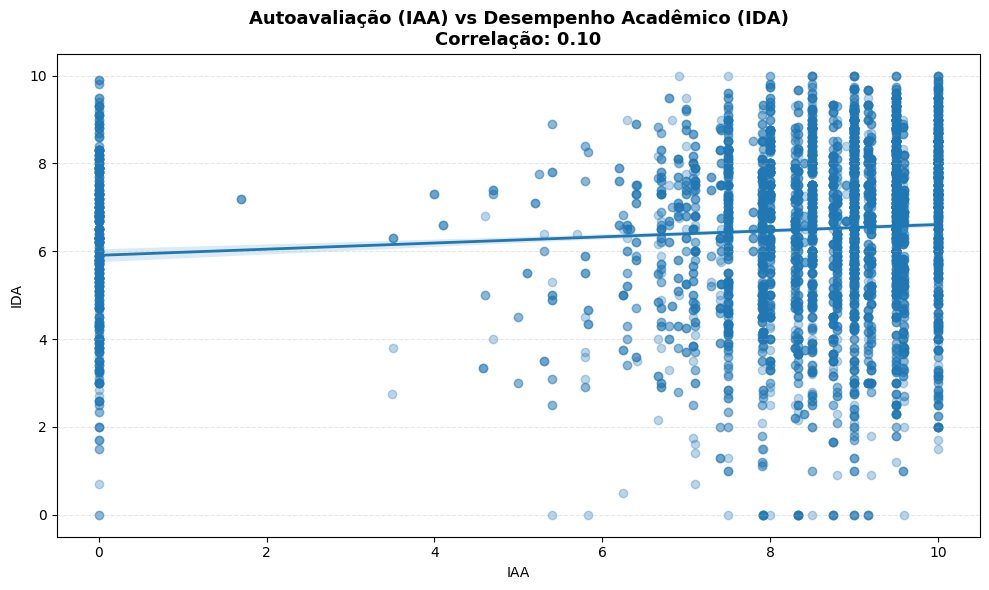

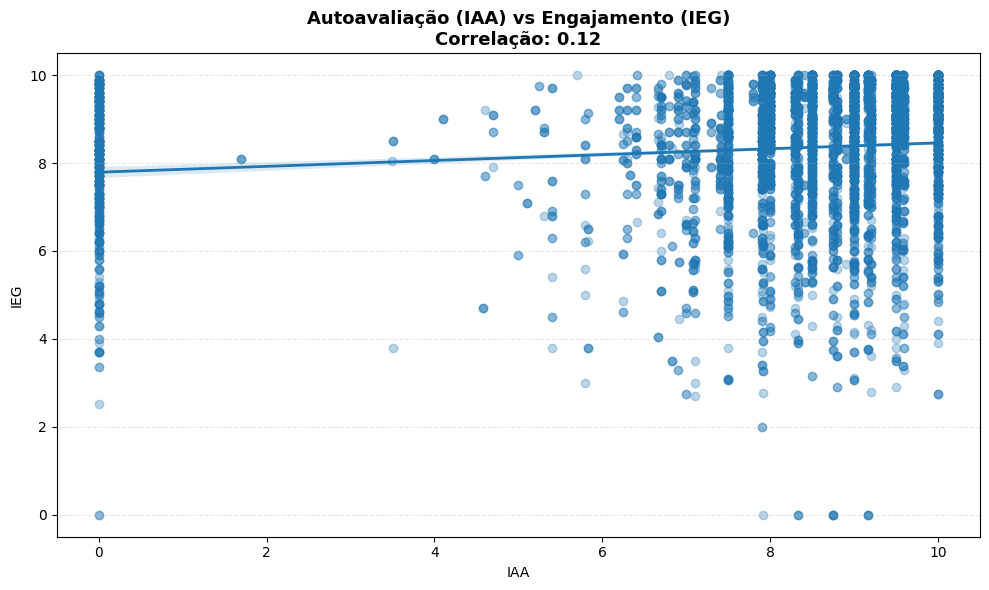

In [ ]:
#Função reutilizável

import matplotlib.pyplot as plt
import seaborn as sns

def analisar_relacao(df, x, y, titulo):
    plt.figure(figsize=(10, 6))

    ax = sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={'alpha': 0.3},
        line_kws={'linewidth': 2}
    )

    corr = df[x].corr(df[y])

    plt.title(f'{titulo}\nCorrelação: {corr:.2f}', fontsize=13, weight='bold')
    plt.xlabel(x)
    plt.ylabel(y)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return corr

#IAA vs IDA

corr_iaa_ida = analisar_relacao(
    df_analise,
    x='IAA',
    y='IDA',
    titulo='Autoavaliação (IAA) vs Desempenho Acadêmico (IDA)'
)

#IAA vs IEG

corr_iaa_ieg = analisar_relacao(
    df_analise,
    x='IAA',
    y='IEG',
    titulo='Autoavaliação (IAA) vs Engajamento (IEG)'
)

Os alunos não conseguem avaliar corretamente seu próprio desempenho.
Um problema de percepção, não de desempenho.

Pode ser falta de feedback claro, ou não percebem evolução ou acham que estão melhor do que realmente estão.

In [ ]:
#Classificação automática

def classificar_correlacao(valor):
    if abs(valor) < 0.3:
        return "Fraca"
    elif abs(valor) < 0.7:
        return "Moderada"
    else:
        return "Forte"

print("\nINTERPRETAÇÃO AUTOMÁTICA:\n")
print(f"IAA vs IDA: {corr_iaa_ida:.2f} → {classificar_correlacao(corr_iaa_ida)}")
print(f"IAA vs IEG: {corr_iaa_ieg:.2f} → {classificar_correlacao(corr_iaa_ieg)}")


INTERPRETAÇÃO AUTOMÁTICA:

IAA vs IDA: 0.10 → Fraca
IAA vs IEG: 0.12 → Fraca


A autoavaliação dos alunos (IAA) apresenta correlação muito fraca com os indicadores de desempenho acadêmico (IDA) e engajamento (IEG), indicando baixa coerência entre a percepção dos alunos e sua realidade acadêmica.

- Autoavaliação não reflete a realidade
- Existe um gap de percepção
- O problema não é desempenho — é consciência do desempenho

#5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [ ]:
df_analise['IPS'].describe()

,IPS
count,6231.000000
mean,6.224240
std,1.812764
min,2.500000
25%,5.000000
50%,7.500000
75%,7.510000
max,10.000000


Insight

Média: 6.22
Concentração entre 5 e 7.5

Interpretação:
A maioria dos alunos apresenta níveis psicossociais adequados, mas existe um grupo minoritário em situação de vulnerabilidade.

O IPS não explica diretamente o desempenho ou o engajamento no mesmo período.

In [ ]:
#Preparar dados temporais


def preparar_dados_temporais(df):
    df = df.sort_values(['RA', 'AnoRef']).copy()

    df['IDA_next'] = df.groupby('RA')['IDA'].shift(-1)
    df['IEG_next'] = df.groupby('RA')['IEG'].shift(-1)

    df['IDA_diff'] = df['IDA_next'] - df['IDA']
    df['IEG_diff'] = df['IEG_next'] - df['IEG']

    return df

df_temp = preparar_dados_temporais(df_analise)

# Remover nulos
df_temp = df_temp.dropna(subset=['IDA_diff', 'IEG_diff'])

# Criar flags de queda


df_temp['IDA_drop'] = df_temp['IDA_diff'] < 0
df_temp['IEG_drop'] = df_temp['IEG_diff'] < 0

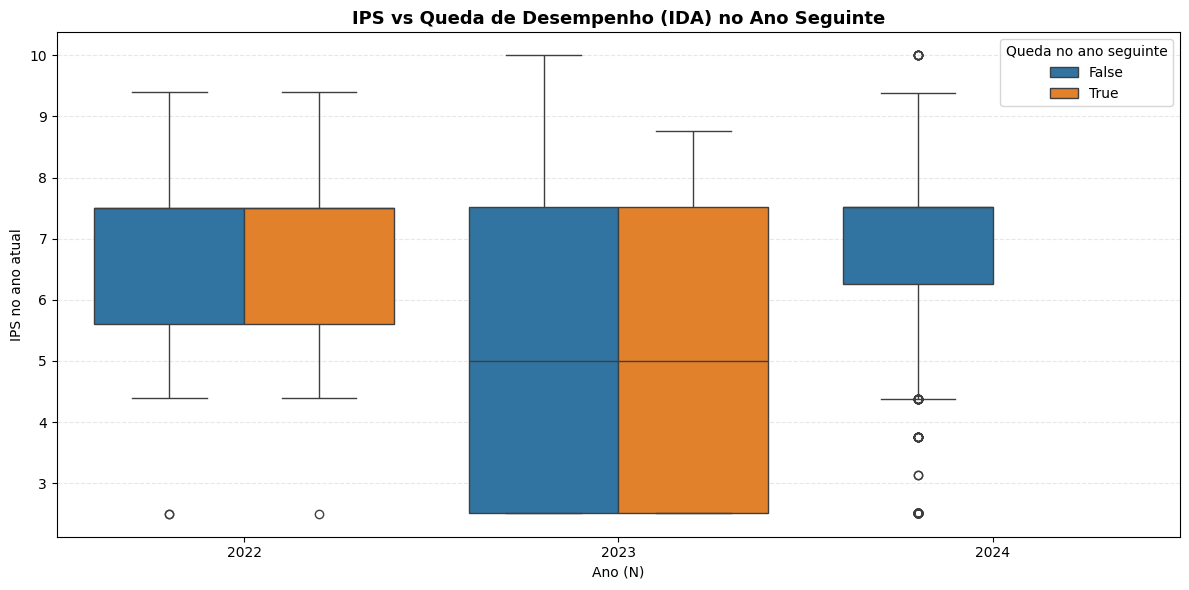

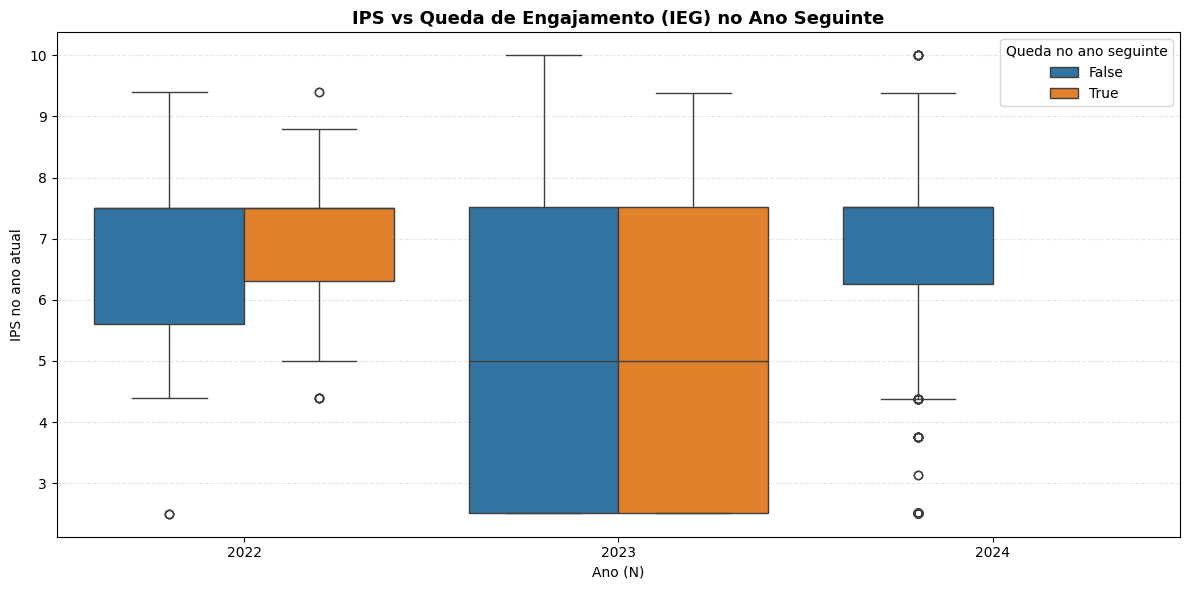

In [ ]:
def plot_boxplot_queda(df, col_drop, titulo):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df,
        x='AnoRef',
        y='IPS',
        hue=col_drop
    )

    plt.title(titulo, fontsize=13, weight='bold')
    plt.xlabel('Ano (N)')
    plt.ylabel('IPS no ano atual')

    plt.legend(title='Queda no ano seguinte')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# IDA
plot_boxplot_queda(df_temp, 'IDA_drop',
                   'IPS vs Queda de Desempenho (IDA) no Ano Seguinte')

# IEG
plot_boxplot_queda(df_temp, 'IEG_drop',
                   'IPS vs Queda de Engajamento (IEG) no Ano Seguinte')

Não há diferença relevante entre Alunos que tiveram queda e Alunos que não tiveram queda

O IPS atual não diferencia quem vai cair ou não no futuro.
Aspectos psicossociais isoladamente não são bons preditores de queda futura

In [ ]:
def resumo_quedas(df):
    print("\nRESUMO DE QUEDAS:\n")

    print(f"Queda no IDA: {df['IDA_drop'].mean()*100:.1f}%")
    print(f"Queda no IEG: {df['IEG_drop'].mean()*100:.1f}%")

resumo_quedas(df_temp)


RESUMO DE QUEDAS:

Queda no IDA: 14.6%
Queda no IEG: 14.4%


Os aspectos psicossociais (IPS) não apresentam relação significativa com quedas futuras no desempenho acadêmico (IDA) ou no engajamento (IEG), indicando que não são um preditor robusto quando analisados de forma isolada.

#6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [ ]:
#Estatísticas do IPP


def resumo_ipp(df):
    stats = df['IPP'].describe()
    nulos = df['IPP'].isnull().sum()

    print("Estatísticas do IPP:")
    display(stats)

    print(f"\nValores nulos: {nulos}")

resumo_ipp(df_analise)

Estatísticas do IPP:


,IPP
count,6231.000000
mean,7.479308
std,0.888949
min,2.500000
25%,6.937500
50%,7.500000
75%,8.125000
max,10.000000



Valores nulos: 0


Interpretação:

Média: ~7.48,
Mediana: 7.5,
Baixa dispersão (std ~0.88)

Insight:

A maioria dos alunos apresenta níveis psicopedagógicos relativamente bons e homogêneos.

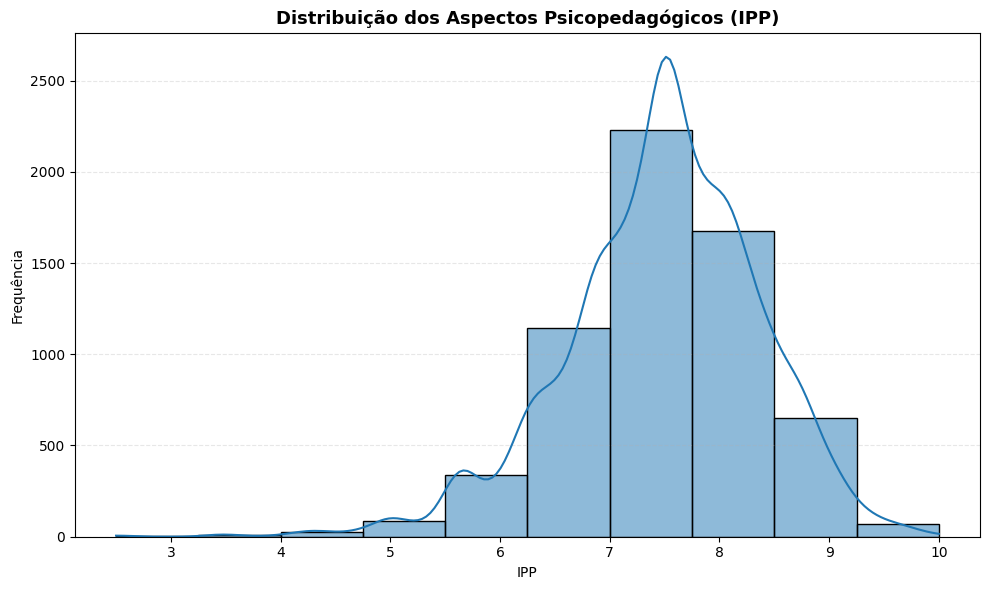

In [ ]:
#Distribuição

def plot_distribuicao_ipp(df):
    plt.figure(figsize=(10, 6))

    sns.histplot(df['IPP'], bins=10, kde=True)

    plt.title('Distribuição dos Aspectos Psicopedagógicos (IPP)', fontsize=13, weight='bold')
    plt.xlabel('IPP')
    plt.ylabel('Frequência')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_distribuicao_ipp(df_analise)

/tmp/ipykernel_2056/1251708224.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


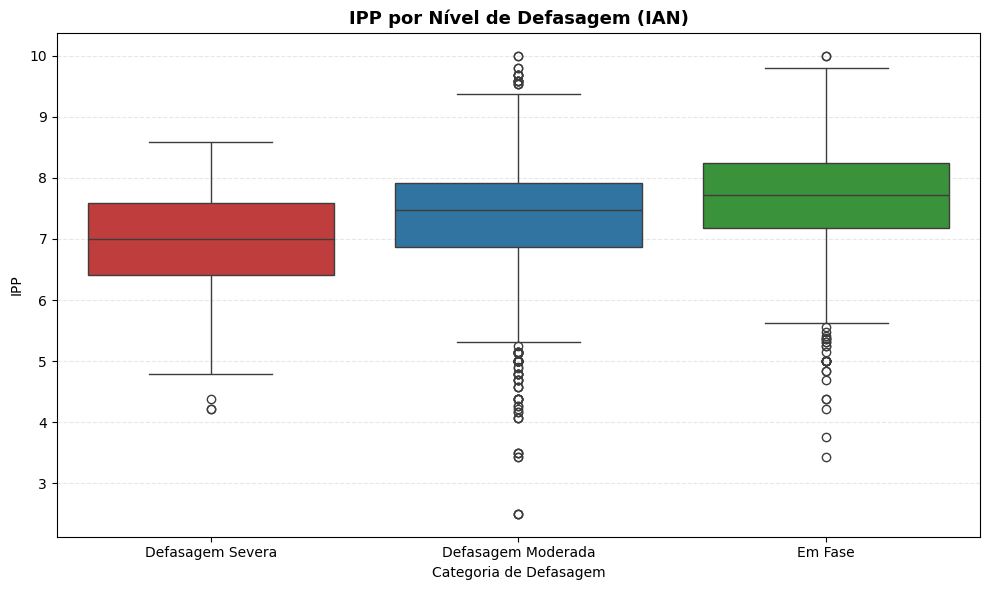

In [ ]:
#Comparação por grupo (IAN)

def plot_ipp_por_ian(df):
    plt.figure(figsize=(10, 6))

    ordem = ['Defasagem Severa', 'Defasagem Moderada', 'Em Fase']

    palette = {
        'Defasagem Severa': '#d62728',
        'Defasagem Moderada': '#1f77b4',
        'Em Fase': '#2ca02c'
    }

    sns.boxplot(
        data=df,
        x='IAN_grupo',
        y='IPP',
        order=ordem,
        palette=palette
    )

    plt.title('IPP por Nível de Defasagem (IAN)', fontsize=13, weight='bold')
    plt.xlabel('Categoria de Defasagem')
    plt.ylabel('IPP')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_ipp_por_ian(df_analise)

In [ ]:
#Correlação

corr_ipp_ian = df_analise['IPP'].corr(df_analise['IAN'])

print(f"\nCorrelação IPP vs IAN: {corr_ipp_ian:.2f}")


Correlação IPP vs IAN: 0.20


In [ ]:
#Médias por grupo

media_por_grupo = df_analise.groupby('IAN_grupo')['IPP'].mean().sort_values()

print("\nMédia de IPP por grupo:")
display(media_por_grupo)


Média de IPP por grupo:


,IPP
IAN_grupo,
Defasagem Severa,6.901894
Defasagem Moderada,7.338743
Em Fase,7.681304


- O IAN (defasagem) está bem calibrado.
- O IPP está coerente com a realidade acadêmica.
- Os indicadores se reforçam mutuamente.

As avaliações psicopedagógicas (IPP) apresentam forte alinhamento com os níveis de defasagem identificados pelo IAN, confirmando que alunos com maior defasagem tendem a apresentar menores índices psicopedagógicos, enquanto alunos em fase adequada apresentam melhores resultados.

#7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

=== Correlação Direta (Mesmo Ano) ===


,Indicador,Correlação
0,IDA,0.566202
1,IEG,0.563852
4,IPP,0.483209
2,IAA,0.043263
3,IPS,-0.049931


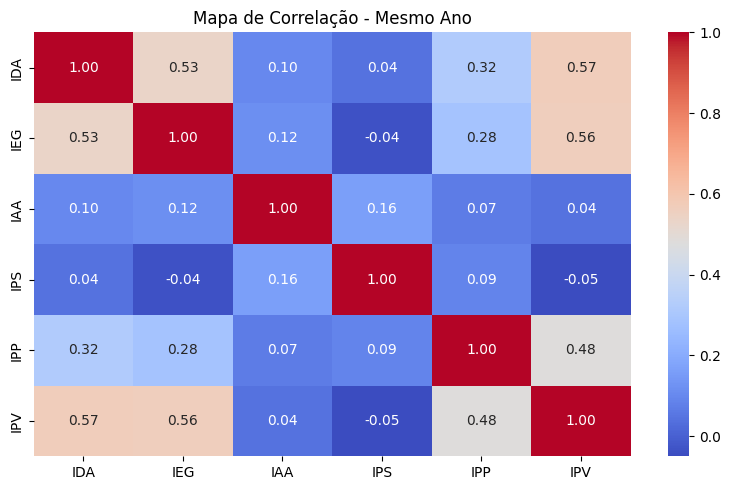

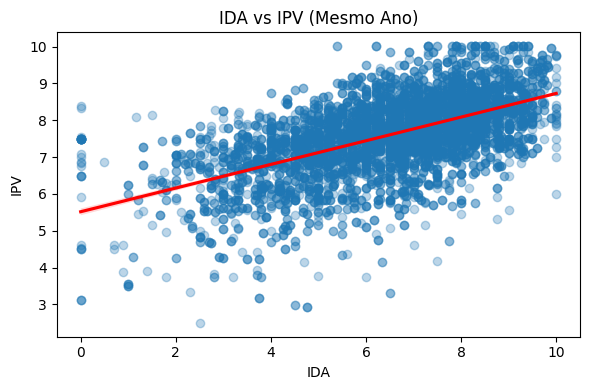

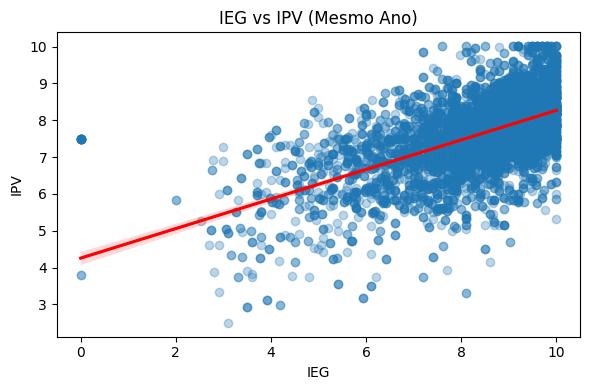

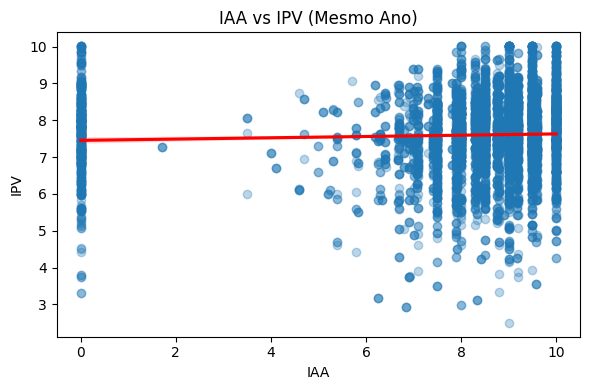

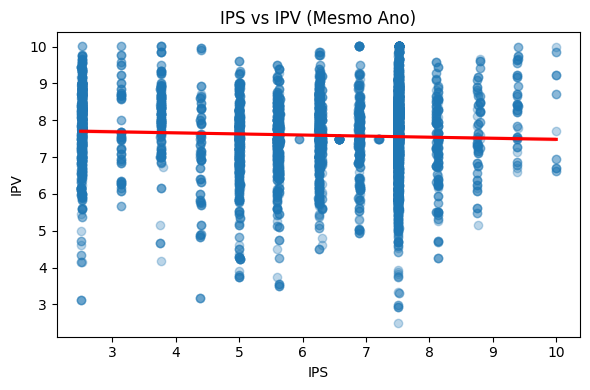

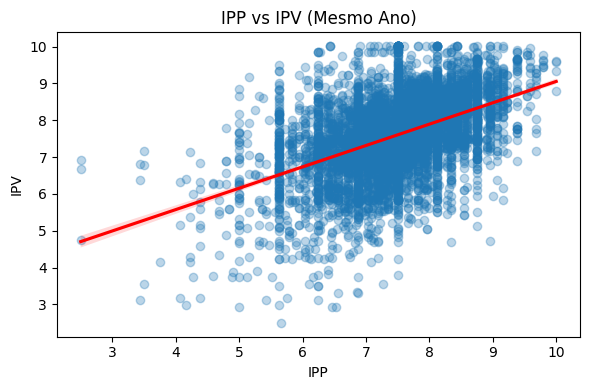


=== Correlação Temporal (Ano N → Ano N+1) ===


,Indicador,Correlação
0,IDA,0.516468
1,IEG,0.490584
4,IPP,0.489351
2,IAA,0.082004
3,IPS,0.029625


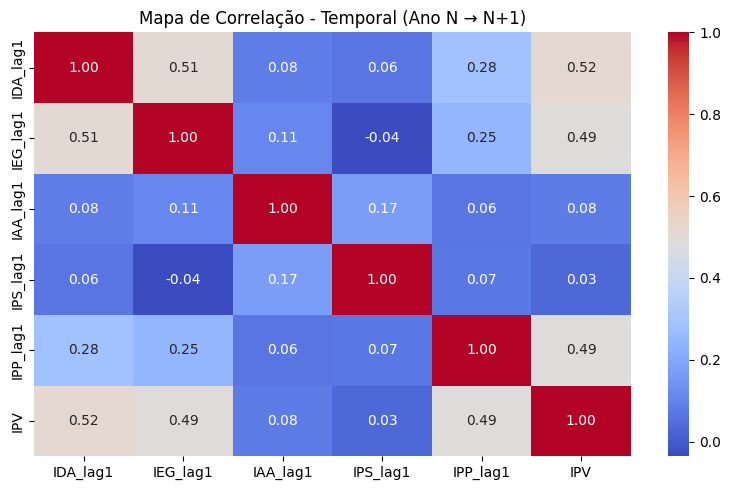

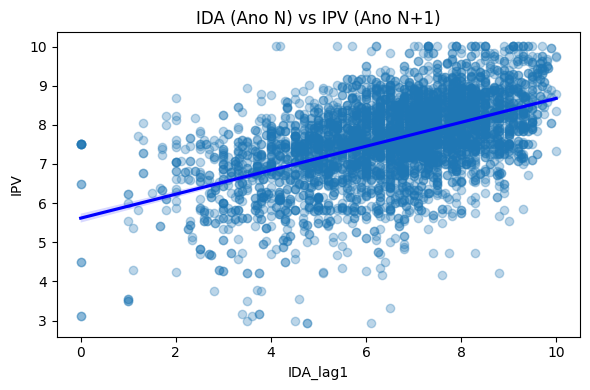

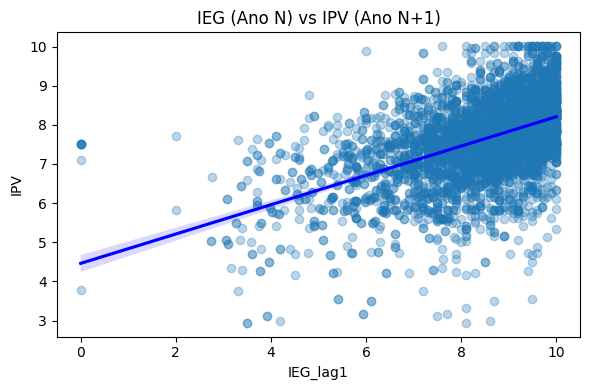

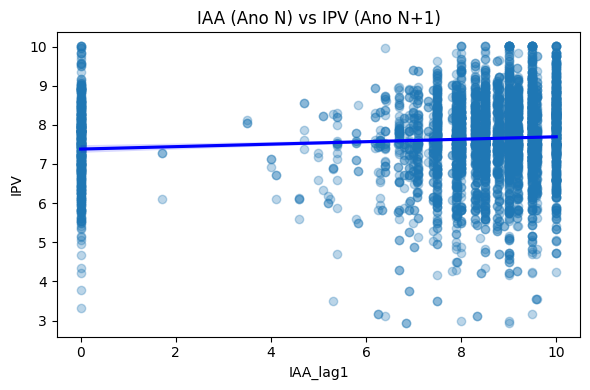

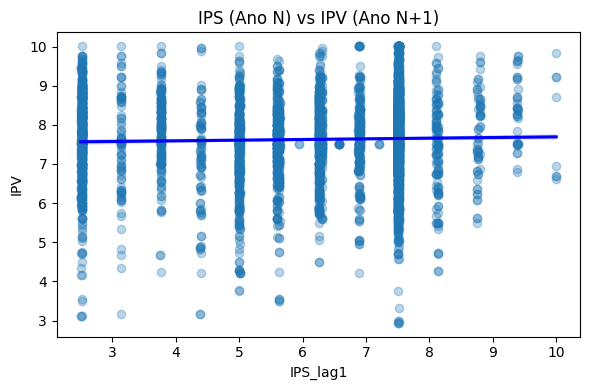

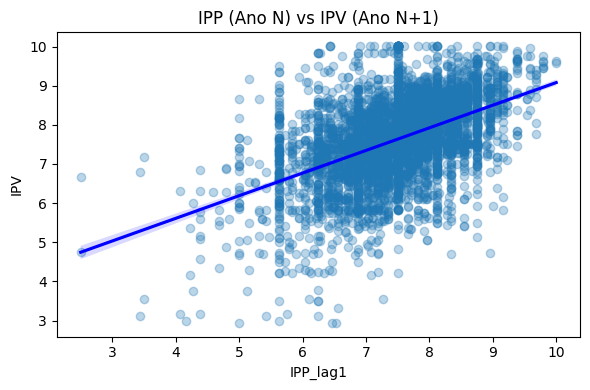

In [ ]:
# CONFIGURAÇÕES INICIAIS

indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP']
target = 'IPV'

# CORRELAÇÃO DIRETA

print("=== Correlação Direta (Mesmo Ano) ===")

correlacoes_diretas = []

for col in indicadores:
    corr = df_analise[col].corr(df_analise[target])
    correlacoes_diretas.append((col, corr))

# Criar DataFrame de correlação
df_corr_direta = pd.DataFrame(correlacoes_diretas, columns=['Indicador', 'Correlação'])
df_corr_direta = df_corr_direta.sort_values(by='Correlação', ascending=False)

display(df_corr_direta)

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_analise[indicadores + [target]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Correlação - Mesmo Ano")
plt.tight_layout()
plt.show()

# Gráficos de dispersão
for col in indicadores:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y=target, data=df_analise,
                scatter_kws={'alpha':0.3},
                line_kws={'color':'red'})
    plt.title(f'{col} vs IPV (Mesmo Ano)')
    plt.tight_layout()
    plt.show()


# PREPARAÇÃO TEMPORAL

df_temp = df_analise.copy()
df_temp = df_temp.sort_values(by=['RA', 'AnoRef'])

for col in indicadores:
    df_temp[f'{col}_lag1'] = df_temp.groupby('RA')[col].shift(1)

# Remover nulos
df_temp_corr = df_temp.dropna(subset=[f'{col}_lag1' for col in indicadores] + [target])


# CORRELAÇÃO TEMPORAL

print("\n=== Correlação Temporal (Ano N → Ano N+1) ===")

correlacoes_temporais = []

for col in indicadores:
    corr = df_temp_corr[f'{col}_lag1'].corr(df_temp_corr[target])
    correlacoes_temporais.append((col, corr))

df_corr_temp = pd.DataFrame(correlacoes_temporais, columns=['Indicador', 'Correlação'])
df_corr_temp = df_corr_temp.sort_values(by='Correlação', ascending=False)

display(df_corr_temp)

# Heatmap temporal
cols_lag = [f'{col}_lag1' for col in indicadores]

plt.figure(figsize=(8, 5))
sns.heatmap(df_temp_corr[cols_lag + [target]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Correlação - Temporal (Ano N → N+1)")
plt.tight_layout()
plt.show()

# Gráficos de dispersão temporal
for col in indicadores:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=f'{col}_lag1', y=target, data=df_temp_corr,
                scatter_kws={'alpha':0.3},
                line_kws={'color':'blue'})
    plt.title(f'{col} (Ano N) vs IPV (Ano N+1)')
    plt.tight_layout()
    plt.show()

**Correlação Direta (Mesmo Ano)**

Os resultados mostram:

- IDA (Desempenho Acadêmico) → ~0.57
- IEG (Engajamento) → ~0.56,
- IPP (Psicopedagógico) → ~0.48

Esses três apresentam correlação moderada a forte positiva com o IPV.


Alunos que aprendem mais (IDA), participam mais (IEG) e têm melhor suporte cognitivo (IPP) tendem a atingir mais o ponto de virada no mesmo ano.

Já os demais:

- IAA (Autoavaliação) → ~0.04
- IPS (Psicossocial) → ~0
-  Correlação praticamente nula

A percepção do aluno sobre si mesmo não reflete seu desempenho real

Fatores psicossociais não impactam diretamente o IPV (no curto prazo).

C**orrelação Temporal (Ano N → Ano N+1)**

Aqui avaliamos causalidade indireta (tendência):

IDA (N) → IPV (N+1) → ~0.52

IEG (N) → IPV (N+1) → ~0.49

IPP (N) → IPV (N+1) → ~0.49

Continua forte/moderado

Bom desempenho e engajamento se acumulam ao longo do tempo

O IPV não é um evento isolado → é construído

Os comportamentos que mais influenciam o IPV são:

Principais drivers (impacto real):

IDA (acadêmico) → base do progresso

IEG (engajamento) → motor do aprendizado

IPP (psicopedagógico) → suporte estrutural

Baixo impacto direto:

IAA (autoimagem)

IPS (psicossocial)

Importantes, mas não determinantes para performance mensurável

Insight de Negócio (esse aqui é ouro pra apresentação)

- O IPV é resultado de comportamento consistente, não de percepção.

- Ou seja:

Não adianta o aluno “achar que está bem” (IAA)

O que importa é:

estudar (IDA)

participar (IEG)

ter base cognitiva (IPP)

#8. Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

In [ ]:
# Selecionar colunas relevantes
df_multidimensionalidade = df_analise[['IDA', 'IEG', 'IPS', 'IPP', 'INDE']].copy()

print("DataFrame preparado:")
display(df_multidimensionalidade.head())

print("\nValores nulos:")
display(df_multidimensionalidade.isnull().sum())

DataFrame preparado:


,IDA,IEG,IPS,IPP,INDE
0,4.0,4.1,5.6,7.437500,5.783
1,6.8,5.2,6.3,7.443750,7.055
2,5.6,7.9,5.6,7.193750,6.591
3,5.0,4.5,5.6,6.316667,5.951
4,5.2,8.6,5.6,7.500000,7.427



Valores nulos:


,0
IDA,0
IEG,0
IPS,0
IPP,0
INDE,0


Matriz de Correlação:


,IDA,IEG,IPS,IPP,INDE
IDA,1.000000,0.532969,0.041076,0.320306,0.773590
IEG,0.532969,1.000000,-0.036422,0.284515,0.733124
IPS,0.041076,-0.036422,1.000000,0.087515,0.220448
IPP,0.320306,0.284515,0.087515,1.000000,0.471021
INDE,0.773590,0.733124,0.220448,0.471021,1.000000


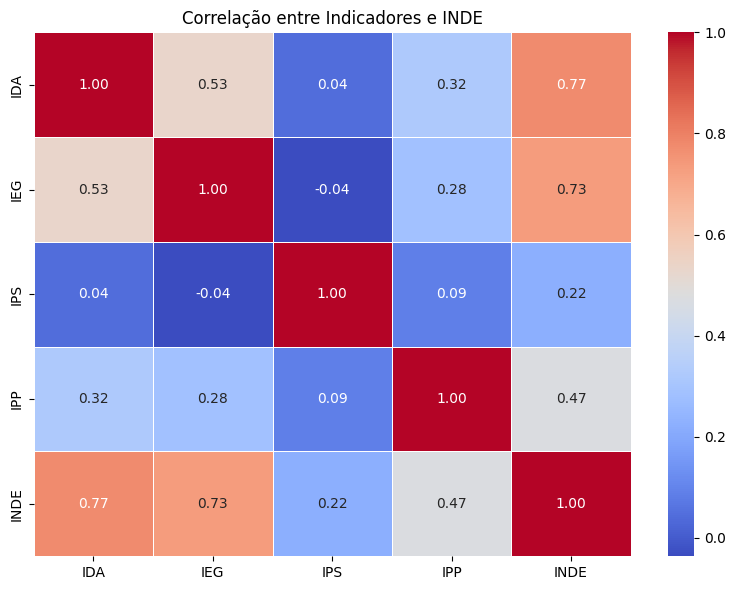

In [ ]:
# Matriz de correlação
correlation_matrix = df_multidimensionalidade.corr()

print("Matriz de Correlação:")
display(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlação entre Indicadores e INDE')
plt.tight_layout()
plt.show()

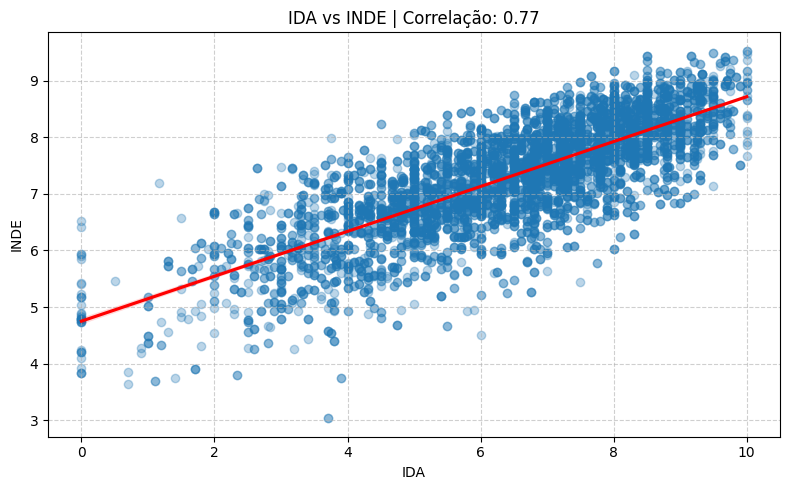

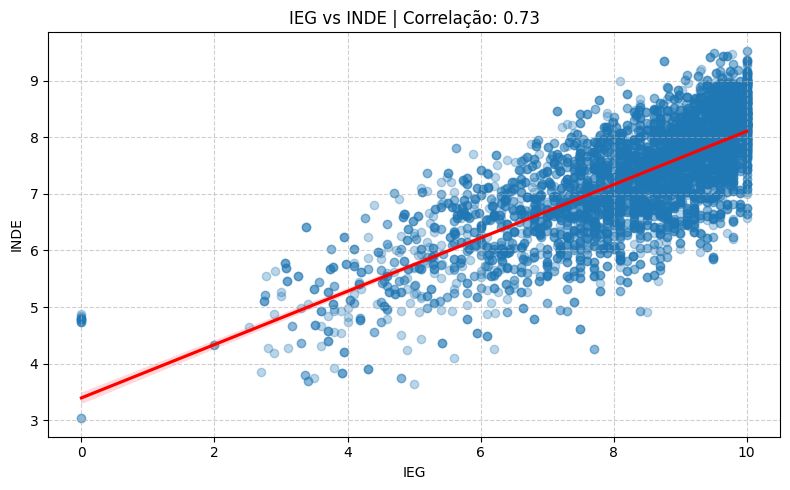

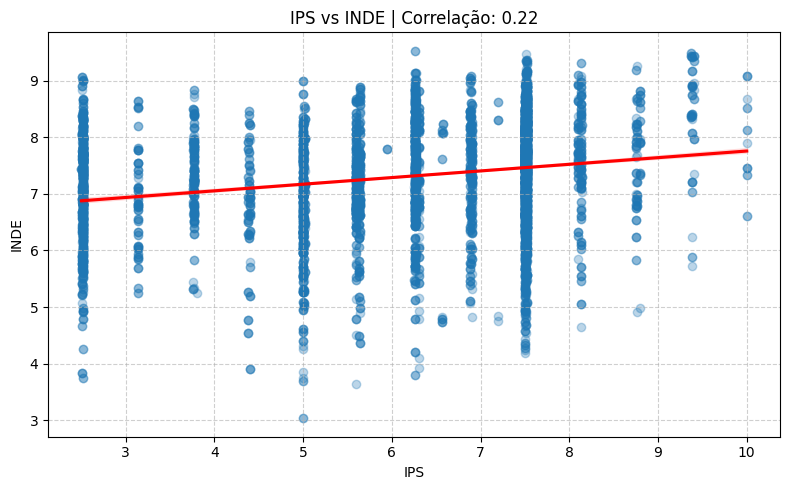

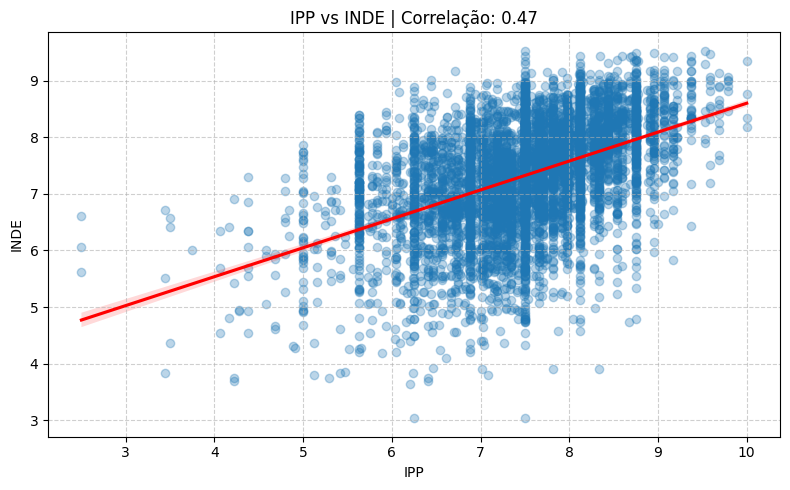

In [ ]:
indicadores = ['IDA', 'IEG', 'IPS', 'IPP']

for col in indicadores:
    plt.figure(figsize=(8, 5))
    sns.regplot(x=col, y='INDE', data=df_multidimensionalidade,
                scatter_kws={'alpha':0.3},
                line_kws={'color':'red'})

    corr = df_multidimensionalidade[col].corr(df_multidimensionalidade['INDE'])

    plt.title(f'{col} vs INDE | Correlação: {corr:.2f}')
    plt.xlabel(col)
    plt.ylabel('INDE')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
# Criar combinações
df_multidimensionalidade['COMBO_IDA_IEG'] = df_multidimensionalidade[['IDA', 'IEG']].mean(axis=1)
df_multidimensionalidade['COMBO_IDA_IEG_IPP'] = df_multidimensionalidade[['IDA', 'IEG', 'IPP']].mean(axis=1)

# Correlações das combinações
corr_combo1 = df_multidimensionalidade['COMBO_IDA_IEG'].corr(df_multidimensionalidade['INDE'])
corr_combo2 = df_multidimensionalidade['COMBO_IDA_IEG_IPP'].corr(df_multidimensionalidade['INDE'])

print(f"Correlação COMBO_IDA_IEG vs INDE: {corr_combo1:.2f}")
print(f"Correlação COMBO_IDA_IEG_IPP vs INDE: {corr_combo2:.2f}")

Correlação COMBO_IDA_IEG vs INDE: 0.86
Correlação COMBO_IDA_IEG_IPP vs INDE: 0.88


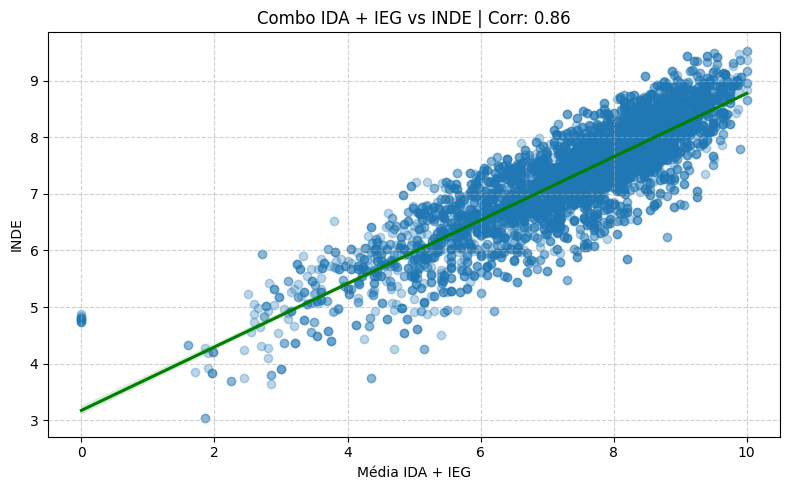

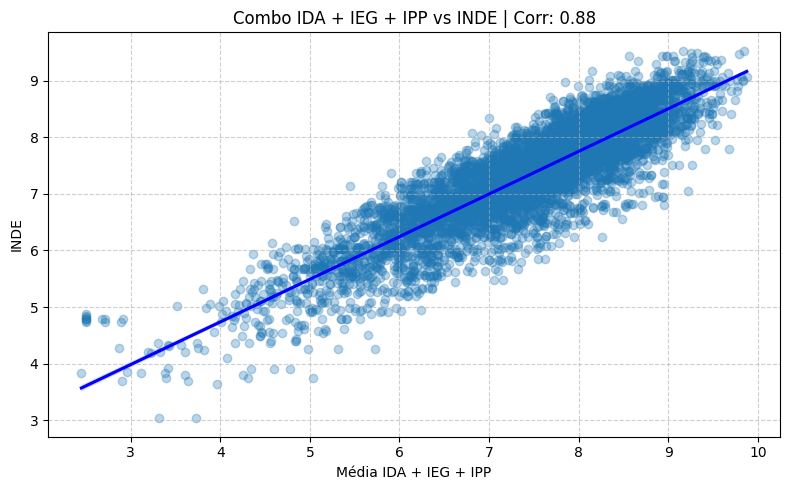

In [ ]:
# Plot combo IDA + IEG
plt.figure(figsize=(8, 5))
sns.regplot(x='COMBO_IDA_IEG', y='INDE', data=df_multidimensionalidade,
            scatter_kws={'alpha':0.3},
            line_kws={'color':'green'})

plt.title(f'Combo IDA + IEG vs INDE | Corr: {corr_combo1:.2f}')
plt.xlabel('Média IDA + IEG')
plt.ylabel('INDE')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot combo IDA + IEG + IPP
plt.figure(figsize=(8, 5))
sns.regplot(x='COMBO_IDA_IEG_IPP', y='INDE', data=df_multidimensionalidade,
            scatter_kws={'alpha':0.3},
            line_kws={'color':'blue'})

plt.title(f'Combo IDA + IEG + IPP vs INDE | Corr: {corr_combo2:.2f}')
plt.xlabel('Média IDA + IEG + IPP')
plt.ylabel('INDE')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Definir variáveis
X = df_multidimensionalidade[['IDA', 'IEG', 'IPS', 'IPP']]
y = df_multidimensionalidade['INDE']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes
coeficientes = pd.DataFrame({
    'Indicador': X.columns,
    'Peso': model.coef_
}).sort_values(by='Peso', ascending=False)

print("Importância dos indicadores (Regressão Linear):")
display(coeficientes)

Importância dos indicadores (Regressão Linear):


,Indicador,Peso
1,IEG,0.279982
0,IDA,0.243595
3,IPP,0.190695
2,IPS,0.106165


In [ ]:
from sklearn.metrics import r2_score

# Previsão
y_pred = model.predict(X_test)

# R²
r2 = r2_score(y_test, y_pred)

print(f"R² do modelo: {r2:.2f}")

R² do modelo: 0.82


A nota global (INDE) é predominantemente influenciada por fatores acadêmicos e comportamentais mensuráveis, com destaque para:

IDA (desempenho) → principal driver

IEG (engajamento) → reforço direto

IPP (psicopedagógico) → suporte estrutural

Enquanto isso:

IPS (psicossocial) apresenta baixa influência direta, podendo atuar de forma indireta

Para elevar o desempenho global dos alunos, as ações mais eficazes devem focar em:

- Melhoria do desempenho acadêmico (IDA)

- Aumento do engajamento (IEG)

- Fortalecimento do suporte psicopedagógico (IPP)

**Intervenções nessas três dimensões tendem a gerar o maior impacto sistêmico no INDE**

#9. Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

In [ ]:
df_risco = df_analise.copy()

# Sort by RA and AnoRef to ensure correct lagging
df_risco = df_risco.sort_values(by=['RA', 'AnoRef'])

print("DataFrame 'df_risco' criado e ordenado com sucesso!")
print("Primeiras 5 linhas do df_risco:")
display(df_risco.head())

DataFrame 'df_risco' criado e ordenado com sucesso!
Primeiras 5 linhas do df_risco:


,RA,Genero,Fase,Defasagem,Pedra,IAN,IDA,IEG,IAA,IPS,IPV,INDE,IPP,AnoRef,IAN_grupo
0,1,Feminino,7,-1,Quartzo,5.0,4.0,4.1,8.3,5.6,7.278,5.783,7.437500,2022,Defasagem Moderada
1,2,Feminino,7,0,Ametista,10.0,6.8,5.2,8.8,6.3,6.778,7.055,7.443750,2022,Em Fase
2,3,Feminino,7,0,Ágata,10.0,5.6,7.9,0.0,5.6,7.556,6.591,7.193750,2022,Em Fase
3,4,Masculino,7,0,Quartzo,10.0,5.0,4.5,8.8,5.6,5.278,5.951,6.316667,2022,Em Fase
4,5,Feminino,7,0,Ametista,10.0,5.2,8.6,7.9,5.6,7.389,7.427,7.500000,2022,Em Fase


In [ ]:
df_risco['Defasagem_proximo_ano'] = df_risco.groupby('DefRA')['asagem'].shift(-1)

print("Coluna 'Defasagem_proximo_ano' criada com sucesso!")
print("Primeiras 10 linhas do df_risco com a nova coluna:")
display(df_risco.head(10))
print("Verificando a quantidade de valores nulos na nova coluna:")
print(df_risco['Defasagem_proximo_ano'].isnull().sum())

Coluna 'Defasagem_proximo_ano' criada com sucesso!
Primeiras 10 linhas do df_risco com a nova coluna:


,RA,Genero,Fase,Defasagem,Pedra,IAN,IDA,IEG,IAA,IPS,IPV,INDE,IPP,AnoRef,IAN_grupo,Defasagem_proximo_ano
0,1,Feminino,7,-1,Quartzo,5.0,4.0,4.1,8.3,5.6,7.278,5.783,7.437500,2022,Defasagem Moderada,NaN
1,2,Feminino,7,0,Ametista,10.0,6.8,5.2,8.8,6.3,6.778,7.055,7.443750,2022,Em Fase,NaN
2,3,Feminino,7,0,Ágata,10.0,5.6,7.9,0.0,5.6,7.556,6.591,7.193750,2022,Em Fase,NaN
3,4,Masculino,7,0,Quartzo,10.0,5.0,4.5,8.8,5.6,5.278,5.951,6.316667,2022,Em Fase,NaN
4,5,Feminino,7,0,Ametista,10.0,5.2,8.6,7.9,5.6,7.389,7.427,7.500000,2022,Em Fase,NaN
5,6,Feminino,7,-1,Quartzo,5.0,3.3,4.5,7.9,7.5,7.222,5.848,7.531250,2022,Defasagem Moderada,NaN
6,7,Masculino,7,-1,Ágata,5.0,7.6,8.4,0.0,7.5,7.667,6.818,7.479167,2022,Defasagem Moderada,NaN
7,8,Feminino,7,-1,Quartzo,5.0,1.6,4.6,7.1,6.3,6.278,4.786,7.418750,2022,Defasagem Moderada,NaN
8,9,Feminino,7,-1,Topázio,5.0,6.7,9.5,8.8,7.5,9.500,8.109,7.712500,2022,Defasagem Moderada,NaN
9,10,Feminino,7,-1,Quartzo,5.0,4.1,5.2,8.3,5.0,7.056,5.784,7.281250,2022,Defasagem Moderada,NaN


Verificando a quantidade de valores nulos na nova coluna:
1586


In [ ]:
df_risco['Defasagem'] = df_risco['Defasagem'].astype(float)
df_risco['Defasagem_proximo_ano'] = df_risco['Defasagem_proximo_ano'].astype(float)

df_risco['Risco_Defasagem'] = (df_risco['Defasagem_proximo_ano'] > df_risco['Defasagem']).astype('Int64')

print("Coluna 'Risco_Defasagem' criada com sucesso!")
print("Primeiras 10 linhas do df_risco com a nova coluna:")
display(df_risco.head(10))
print("Verificando a quantidade de valores nulos na nova coluna:")
print(df_risco['Risco_Defasagem'].isnull().sum())
print("Valores únicos na coluna 'Risco_Defasagem':")
display(df_risco['Risco_Defasagem'].value_counts(dropna=False))

Coluna 'Risco_Defasagem' criada com sucesso!
Primeiras 10 linhas do df_risco com a nova coluna:


,RA,Genero,Fase,Defasagem,Pedra,IAN,IDA,IEG,IAA,IPS,IPV,INDE,IPP,AnoRef,IAN_grupo,Defasagem_proximo_ano,Risco_Defasagem
0,1,Feminino,7,-1.0,Quartzo,5.0,4.0,4.1,8.3,5.6,7.278,5.783,7.437500,2022,Defasagem Moderada,NaN,0
1,2,Feminino,7,0.0,Ametista,10.0,6.8,5.2,8.8,6.3,6.778,7.055,7.443750,2022,Em Fase,NaN,0
2,3,Feminino,7,0.0,Ágata,10.0,5.6,7.9,0.0,5.6,7.556,6.591,7.193750,2022,Em Fase,NaN,0
3,4,Masculino,7,0.0,Quartzo,10.0,5.0,4.5,8.8,5.6,5.278,5.951,6.316667,2022,Em Fase,NaN,0
4,5,Feminino,7,0.0,Ametista,10.0,5.2,8.6,7.9,5.6,7.389,7.427,7.500000,2022,Em Fase,NaN,0
5,6,Feminino,7,-1.0,Quartzo,5.0,3.3,4.5,7.9,7.5,7.222,5.848,7.531250,2022,Defasagem Moderada,NaN,0
6,7,Masculino,7,-1.0,Ágata,5.0,7.6,8.4,0.0,7.5,7.667,6.818,7.479167,2022,Defasagem Moderada,NaN,0
7,8,Feminino,7,-1.0,Quartzo,5.0,1.6,4.6,7.1,6.3,6.278,4.786,7.418750,2022,Defasagem Moderada,NaN,0
8,9,Feminino,7,-1.0,Topázio,5.0,6.7,9.5,8.8,7.5,9.500,8.109,7.712500,2022,Defasagem Moderada,NaN,0
9,10,Feminino,7,-1.0,Quartzo,5.0,4.1,5.2,8.3,5.0,7.056,5.784,7.281250,2022,Defasagem Moderada,NaN,0


Verificando a quantidade de valores nulos na nova coluna:
0
Valores únicos na coluna 'Risco_Defasagem':


,count
Risco_Defasagem,
0,5770
1,461


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Cópia do DataFrame
df_modelo = df_risco.copy()

# Conversões de tipos


# Numéricos
df_modelo['Fase'] = df_modelo['Fase'].astype(int)
df_modelo['Defasagem'] = df_modelo['Defasagem'].astype(int)

# Pedra (Ordinal)
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df_modelo['Pedra'] = pd.Categorical(
    df_modelo['Pedra'],
    categories=ordem_pedras,
    ordered=True
).codes

# Gênero (One-Hot)
df_modelo = pd.get_dummies(
    df_modelo,
    columns=['Genero'],
    prefix='Genero',
    dtype=int
)

# Limpeza de dados

df_modelo = df_modelo.dropna(subset=['Risco_Defasagem']).copy()
df_modelo['Risco_Defasagem'] = df_modelo['Risco_Defasagem'].astype(int)

# Separação X e y

y = df_modelo['Risco_Defasagem']

X = df_modelo.drop(columns=[
    'RA',
    'AnoRef',
    'Defasagem_proximo_ano',
    'Risco_Defasagem',
    'IAN_grupo'
])

# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Treinamento

model = LogisticRegression(
    random_state=42,
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# Previsões

y_proba = model.predict_proba(X_test)[:, 1]

# 🔥 Ajuste de threshold (IMPORTANTE)
threshold = 0.4  # você pode testar 0.3, 0.5, 0.6...
y_pred = (y_proba >= threshold).astype(int)

# Avaliação

print("=== Avaliação do Modelo ===\n")

print(f"Threshold utilizado: {threshold}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

# Importância das Features

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print("\n=== Importância das Variáveis ===\n")
print(feature_importance.head(10))

=== Avaliação do Modelo ===

Threshold utilizado: 0.4

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.54      0.69      1732
           1       0.12      0.82      0.21       138

    accuracy                           0.56      1870
   macro avg       0.55      0.68      0.45      1870
weighted avg       0.91      0.56      0.66      1870

AUC-ROC: 0.7629

=== Importância das Variáveis ===

             Feature  Coeficiente
12  Genero_Masculino    -1.512740
11   Genero_Feminino    -1.441327
1          Defasagem    -0.734219
8                IPV     0.725804
9               INDE    -0.513845
5                IEG     0.304392
7                IPS    -0.118962
4                IDA     0.107253
10               IPP    -0.072041
2              Pedra     0.069839


# **Padrões identificados nos dados**

A partir dos coeficientes do modelo (importância das variáveis), é possível identificar padrões claros:

**Indicadores associados a MAIOR risco**

Baixos valores de IEG e IDA
→ indicam dificuldade acadêmica geral

Queda em IPS e IPV
→ possível perda de engajamento / participação

INDE e IPP baixos
→ desempenho inconsistente ao longo do tempo

Defasagem já existente
# → forte indicativo de risco futuro

Indicadores associados a MENOR risco

Altos valores de IAN e IAA
→ bom desempenho contínuo

Pedras mais avançadas (ex: Topázio)
→ alunos em níveis mais altos tendem a menor risco

## **Interpretação prática (insight chave)**

O modelo mostra que o risco de defasagem não acontece de forma repentina.

Ele geralmente é precedido por:

- queda gradual em indicadores acadêmicos

- perda de consistência no desempenho

- sinais de baixo engajamento

# **Probabilidade de risco**

Ao invés de apenas dizer “está em risco ou não”, o modelo fornece algo mais útil:

Probabilidade de risco

Exemplo:

Aluno	Probabilidade	Interpretação
A	0.15	Baixo risco
B	0.45	Atenção
C	0.78	Alto risco

# **Aplicação prática**

Esse modelo permite ações preventivas:

Alertar alunos com probabilidade > 0.4

Intervenções pedagógicas antecipadas

Foco em alunos com queda recente de indicadores

Monitoramento contínuo ao longo do tempo

**Avaliação do modelo**

AUC-ROC: ~0.76 → boa capacidade de separação

Recall alto para risco (~70%)
→ o modelo consegue identificar a maioria dos alunos em risco

Porém:

Baixa precisão (~14%)
→ muitos falsos positivos (alertas desnecessários)

Interpretação correta:

O modelo é melhor para não deixar passar alunos em risco do que para ser totalmente preciso.


Conclusão final

O modelo preditivo desenvolvido demonstrou que o risco de defasagem pode ser antecipado a partir de padrões nos indicadores acadêmicos. Em particular, alunos com baixos desempenhos em métricas como IEG, IDA, INDE e IPP, além de sinais de redução em engajamento (IPS, IPV), apresentam maior probabilidade de entrar em risco.

Além disso, a presença de defasagem atual e níveis acadêmicos mais baixos (Pedra) reforçam esse risco. Por outro lado, indicadores elevados e consistentes ao longo do tempo estão associados a menor probabilidade de defasagem.

O modelo de Regressão Logística permite não apenas classificar os alunos, mas também estimar a probabilidade individual de risco, possibilitando a identificação precoce de casos críticos. Com isso, torna-se possível implementar ações preventivas, como intervenções pedagógicas direcionadas, antes que ocorra queda significativa no desempenho.

Apesar de apresentar boa capacidade de detecção (AUC ≈ 0.76), o modelo prioriza sensibilidade, podendo gerar falsos positivos. Ainda assim, sua aplicação é valiosa em contextos educacionais, onde é preferível antecipar riscos do que ignorá-los.

#10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

Dados agregados:


,AnoRef,Pedra,IDA,IEG,IAA,IPS,IPV,INDE,IPP
0,2022,Ametista,7.050433,8.688133,8.737206,7.054265,7.649000,7.539995,7.546328
1,2022,Quartzo,3.157005,5.433816,6.458937,6.468599,5.836870,5.274986,6.908816
2,2022,Topázio,8.247801,9.315836,9.158651,7.265982,8.380774,8.353845,8.032325
3,2022,Ágata,5.294981,7.702703,8.161004,6.553282,6.871378,6.625237,7.046165
4,2023,Ametista,6.888449,8.943234,7.515512,4.916128,8.154172,7.518033,7.545070


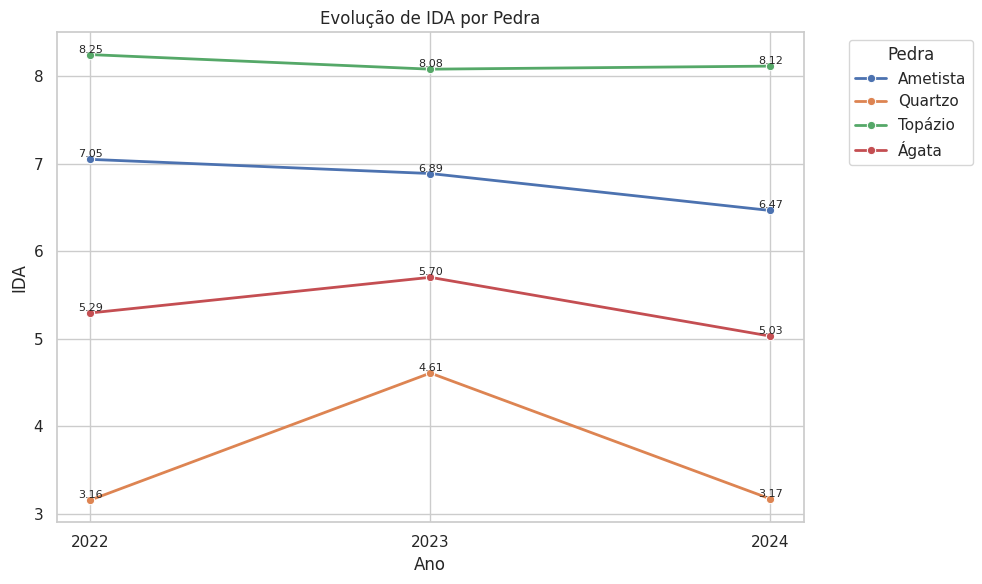

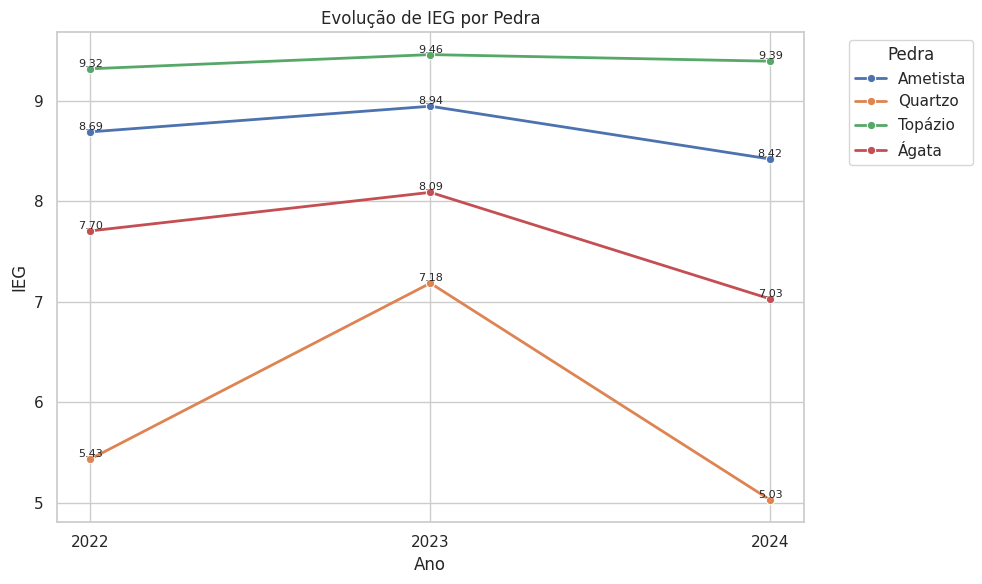

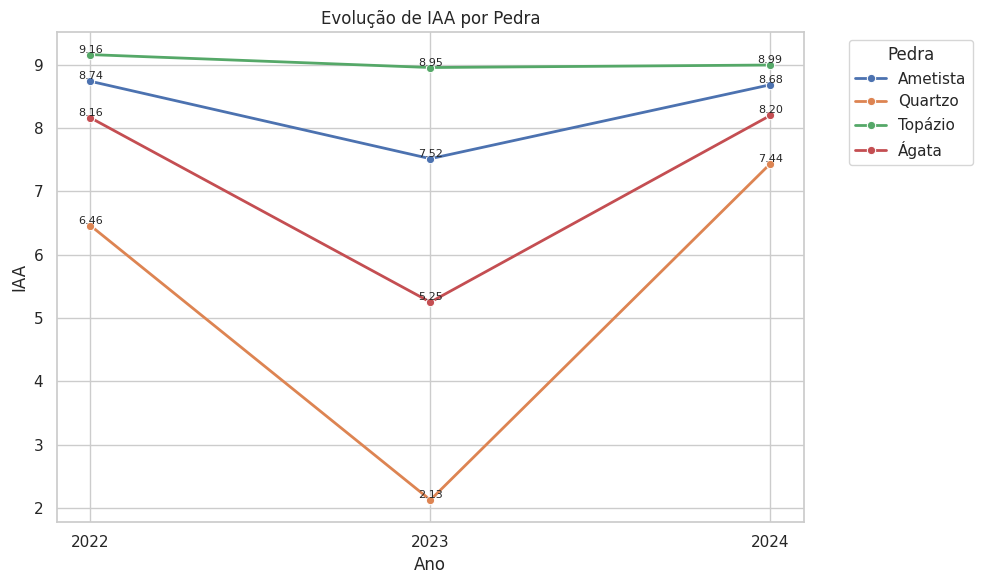

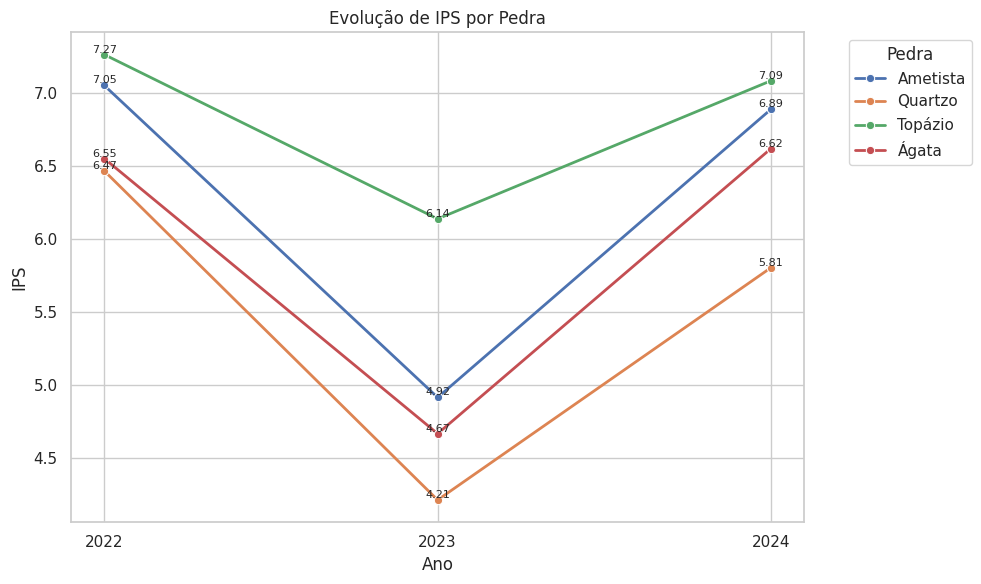

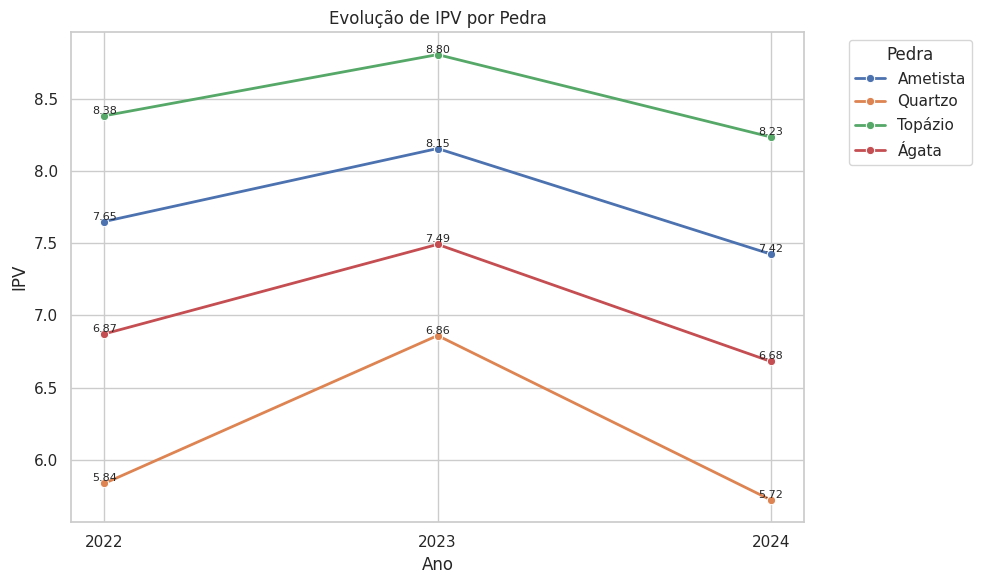

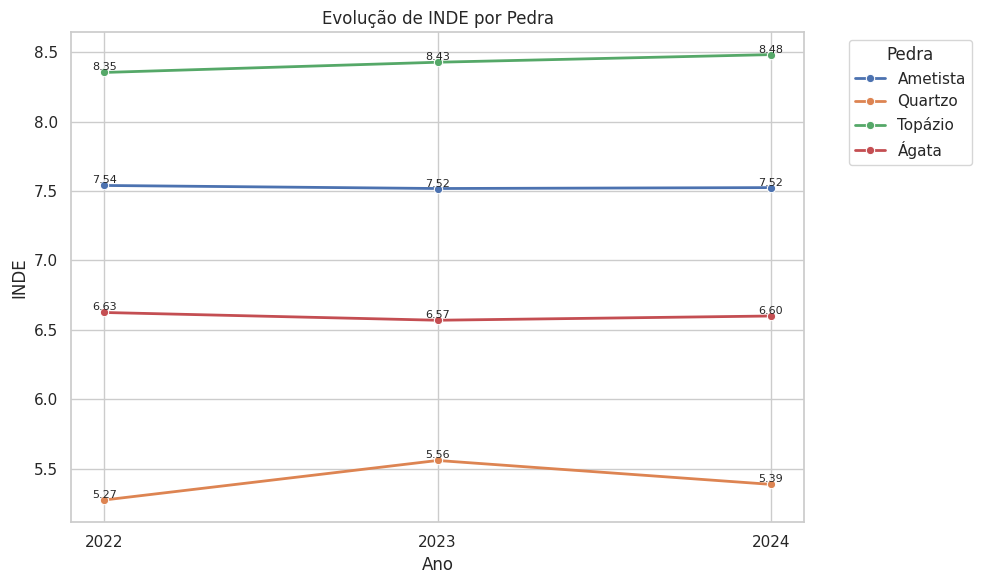

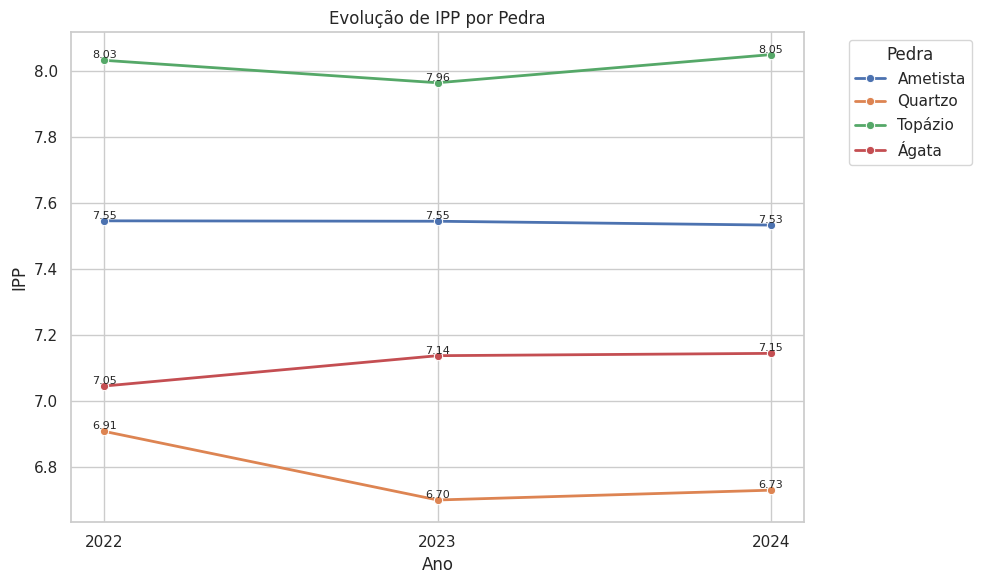


Crescimento percentual do INDE (2022 → 2024):
AnoRef    Crescimento_%
Pedra                  
Quartzo        2.131678
Topázio        1.538986
Ametista      -0.204218
Ágata         -0.381216


In [ ]:
# Configurações iniciais


indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE', 'IPP']

sns.set(style="whitegrid")

# Agregação dos dados

df_pedra = (
    df_analise
    .groupby(['AnoRef', 'Pedra'], observed=False)[indicadores]
    .mean()
    .reset_index()
)

print("Dados agregados:")
display(df_pedra.head())

# Função para plotar gráficos

def plot_indicador(df, indicador):
    plt.figure(figsize=(10, 6))

    ax = sns.lineplot(
        data=df,
        x='AnoRef',
        y=indicador,
        hue='Pedra',
        marker='o',
        linewidth=2
    )

    # Adicionar rótulos nos pontos
    for line in ax.lines:
        label = line.get_label()

        if label != '_nolegend_':
            x_data = line.get_xdata()
            y_data = line.get_ydata()

            for x, y in zip(x_data, y_data):
                ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

    plt.title(f'Evolução de {indicador} por Pedra')
    plt.xlabel('Ano')
    plt.ylabel(indicador)
    plt.xticks(sorted(df['AnoRef'].unique()))
    plt.legend(title='Pedra', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

# Gerar gráficos

for indicador in indicadores:
    plot_indicador(df_pedra, indicador)

# Análise numérica adicional (INSIGHT)

# Crescimento percentual de 2022 → 2024
df_growth = df_pedra.pivot(index='Pedra', columns='AnoRef', values='INDE')

df_growth['Crescimento_%'] = (
    (df_growth[2024] - df_growth[2022]) / df_growth[2022]
) * 100

print("\nCrescimento percentual do INDE (2022 → 2024):")
print(df_growth[['Crescimento_%']].sort_values(by='Crescimento_%', ascending=False))

O estudo da evolução dos indicadores ao longo das fases do programa (Quartzo, Ágata, Ametista e Topázio) demonstra que há um padrão consistente de melhoria no desempenho acadêmico e no engajamento dos alunos. Observa-se que, à medida que os alunos avançam nas fases, os valores médios dos indicadores aumentam progressivamente, indicando o impacto positivo do programa no desenvolvimento educacional.

Além disso, a análise temporal revela uma melhora significativa entre 2022 e 2023 na maioria dos indicadores, como IDA, IEG, INDE e IPP, evidenciando ganhos relevantes em desempenho, engajamento e aspectos psicopedagógicos. Em 2024, observa-se uma leve queda ou estabilização em alguns indicadores, o que pode estar associado a fatores externos, ajustes no programa ou um processo de normalização após um período de crescimento.

Por outro lado, indicadores como IAA (autoavaliação) e IPS (aspectos psicossociais) apresentaram oscilações mais relevantes, sugerindo que o desenvolvimento emocional e a percepção dos alunos podem não acompanhar na mesma intensidade os ganhos acadêmicos.

De forma geral, os resultados confirmam que o programa possui impacto positivo e consistente, especialmente no desempenho acadêmico e engajamento, embora haja oportunidades de melhoria nos aspectos psicossociais e de autoavaliação dos alunos.

#11. Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

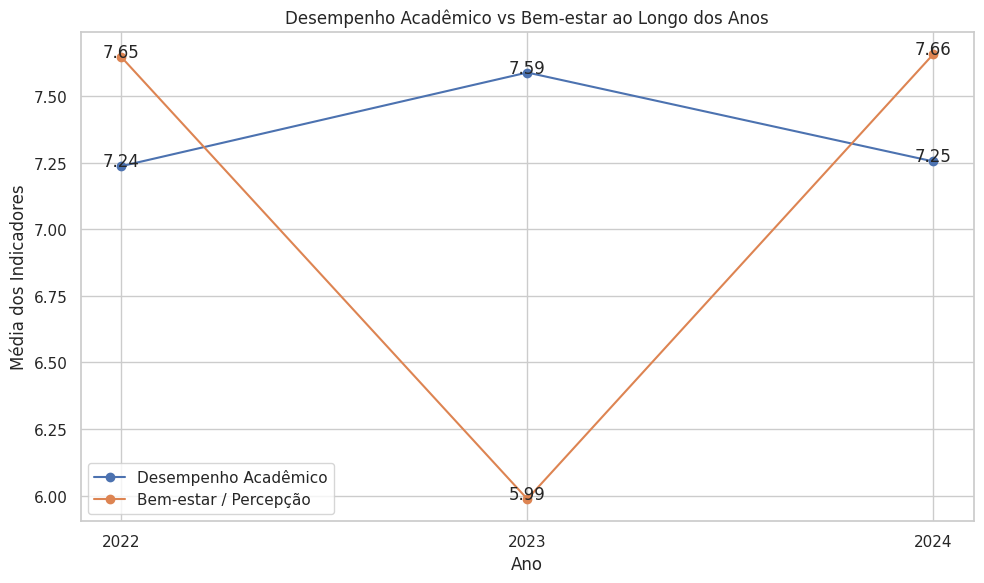

In [ ]:
# Agrupar por ano

indicadores_desempenho = ['IDA', 'IEG', 'INDE']
indicadores_bem_estar = ['IPS', 'IAA']

df_ano = df_analise.groupby('AnoRef')[indicadores_desempenho + indicadores_bem_estar].mean().reset_index()

# Criar métricas agregadas


df_ano['Desempenho_Medio'] = df_ano[indicadores_desempenho].mean(axis=1)
df_ano['BemEstar_Medio'] = df_ano[indicadores_bem_estar].mean(axis=1)

# Plotar gráfico


plt.figure(figsize=(10, 6))

plt.plot(df_ano['AnoRef'], df_ano['Desempenho_Medio'], marker='o', label='Desempenho Acadêmico')
plt.plot(df_ano['AnoRef'], df_ano['BemEstar_Medio'], marker='o', label='Bem-estar / Percepção')

# Rótulos nos pontos
for i in range(len(df_ano)):
    plt.text(df_ano['AnoRef'][i], df_ano['Desempenho_Medio'][i], f"{df_ano['Desempenho_Medio'][i]:.2f}", ha='center')
    plt.text(df_ano['AnoRef'][i], df_ano['BemEstar_Medio'][i], f"{df_ano['BemEstar_Medio'][i]:.2f}", ha='center')

# Layout
plt.title('Desempenho Acadêmico vs Bem-estar ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Média dos Indicadores')
plt.xticks(df_ano['AnoRef'])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Além das análises realizadas, um insight relevante identificado é o possível descompasso entre o desempenho acadêmico e os aspectos emocionais dos alunos. Enquanto indicadores como IDA, IEG e INDE demonstram melhora ao longo do tempo e avanço nas fases do programa, indicadores como IPS (aspectos psicossociais) e IAA (autoavaliação) apresentam queda ou maior instabilidade.

Esse padrão sugere que, embora o programa esteja sendo eficaz na melhoria do desempenho e engajamento, pode haver um aumento de pressão ou desafios emocionais não capturados diretamente pelos indicadores acadêmicos.

Dessa forma, uma oportunidade para a Passos Mágicos seria fortalecer iniciativas voltadas ao acompanhamento emocional e psicossocial dos alunos, garantindo que o desenvolvimento acadêmico esteja alinhado ao bem-estar geral. Isso pode contribuir para resultados ainda mais sustentáveis no longo prazo.